# Final Project, Part I (individual). Clustering and Manifold Learning

### Student ID: 918589943
### Student Name: Chiyang Chen

In [271]:
# Note: Do not change anything

import numpy as np
from numpy import genfromtxt
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from matplotlib import colors
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.image import imread
import os

%matplotlib inline

## Part 1. Comparing different clustering methods

Perform clustering on the dataset `comparing_cluster_methods.csv`. Use DBSCAN, k-means, and mean shift. Plot separately and compare the results. Find the methods that are able to seperate the three clusters (of course, in order to get a meaningful result, one needs to find suitable tuning parameters), and explain why they are able to seperate the clusters, while some other methods cannot.

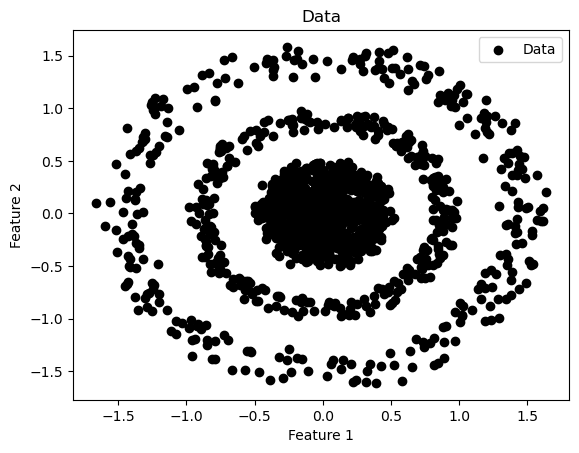

In [273]:
## plot the data

# Load the dataset
data = pd.read_csv('data/comparing_cluster_methods.csv')

# Extract the features
X = data.values

# Perform clustering using DBSCAN
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.25, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)



# Perform clustering using mean shift
from sklearn.cluster import MeanShift

mean_shift = MeanShift()
mean_shift_labels = mean_shift.fit_predict(X)

# Plot the data
plt.scatter(X[:, 0], X[:, 1], c='black', marker='o', label='Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Data')
plt.legend()
plt.show()




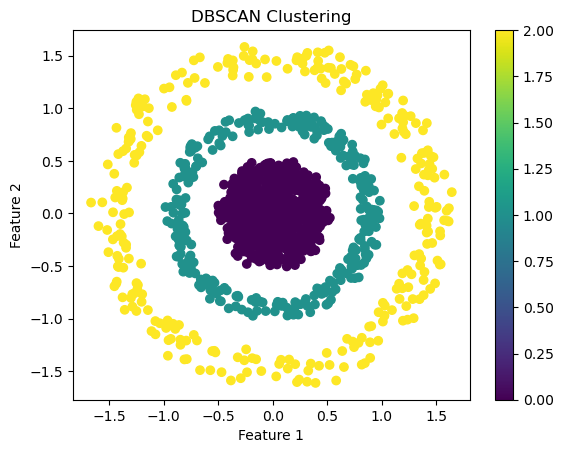

In [274]:
# Plot the result from DBSCAN

plt.scatter(X[:, 0], X[:, 1], c=dbscan_labels, cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('DBSCAN Clustering')
plt.colorbar()
plt.show()







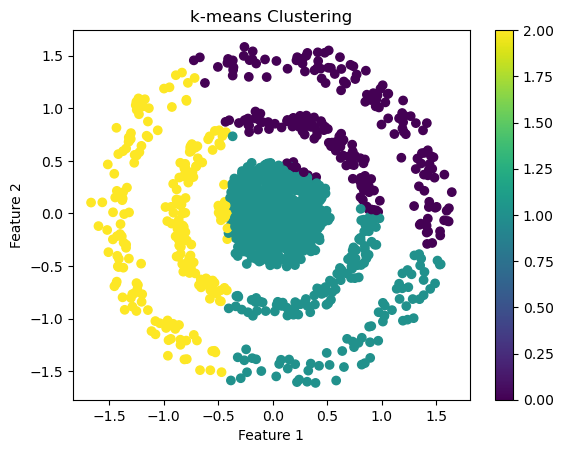

In [275]:
# Plot the result from k-means

# Perform clustering using k-means
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0,n_init = 15)
kmeans_labels = kmeans.fit_predict(X)



plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('k-means Clustering')
plt.colorbar()
plt.show()





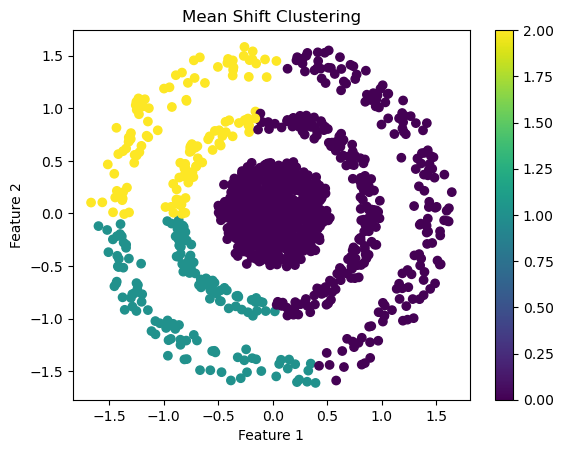

In [276]:
# Plot the result from mean shift

plt.scatter(X[:, 0], X[:, 1], c=mean_shift_labels, cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Mean Shift Clustering')
plt.colorbar()
plt.show()




Q: Compare the three methods and analyze their performance on this dataset.

A:   
DBSCAN: DBSCAN (Density-Based Spatial Clustering with Noise Application) is a density-based clustering algorithm that defines clusters of data points as densely connected regions in the data space. The advantage of this approach is that clusters of arbitrary shapes can be found and noise can be handled. In this case, DBSCAN performs best, probably because this algorithm can identify complex ring structures.

K-means: K-means is a divisional clustering method that clusters data based on centroids by minimizing the sum of the squares of the distances from each data point to the centroid of the class to which it belongs. However, K-means assumes that clusters are convex and isotropic, which makes it weak at identifying clusters with complex shapes such as rings or arcs.

Mean Shift: Mean Shift is a clustering method based on a gradient ascent process that clusters candidate clusters by continuously updating their centers to the average of their neighbors. mean shift does not require a predetermined number of clusters and can handle clusters of arbitrary shapes. However, in this example, Mean Shift does not identify the structure of nested rings well, as this structure may make the process of updating cluster centers difficult.

DBSCAN performs the best in this example, mainly because its density-based clustering strategy allows it to identify nest rings structures in the data.

## Part 2. Data Visualization

Use methods in the course to visualize data 1~5. You need to find a visualization method that is suitable for each data, and for high dimensional data you will need to do dimension reduction. Describe the discovered shape by plots and words.

The difficulty is ranked in order.

Hint: for 3d plots, one can plot it in python in order to change the viewing angles to have a better visual impression.

Hint: MDS and locally linear embedding are the ways to go for higher dimension data.

**Example: Dataset 1**

In [277]:
# Plot
df=pd.read_csv("data/dataset1.csv",header=None)
df.columns=["x","y"]

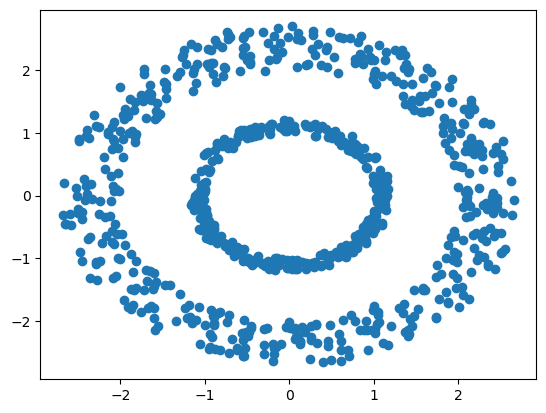

In [278]:
plt.scatter(df.x,df.y)
plt.show()

Description: two nested rings.

Dataset 2.

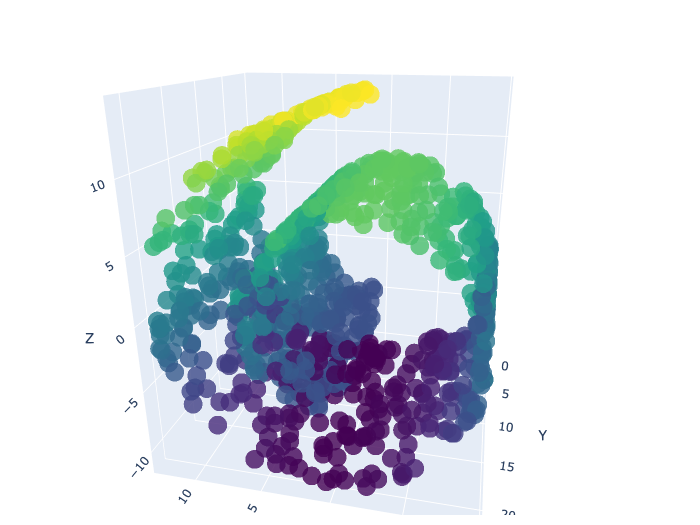

In [279]:
# Plot
import plotly.graph_objects as go
import pandas as pd
from IPython.display import Image
 


# Load dataset 2
df2 = pd.read_csv("data/dataset2.csv", header=None)
df2.columns = ["x", "y", "z"]

# Create 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=df2['x'],
    y=df2['y'],
    z=df2['z'],
    mode='markers',
    marker=dict(
        size=6,
        color=df2['z'],                # set color to an array/list of desired values
        colorscale='Viridis',   # choose a colorscale
        opacity=0.8
    )
)])

# Set labels
fig.update_layout(scene = dict(
                    xaxis_title='X',
                    yaxis_title='Y',
                    zaxis_title='Z'),
                    width=700,
                    margin=dict(r=20, l=10, b=10, t=10))

fig.show()


Image(filename='newplot.png')

Description: One scroll-shaped 3d clustering



Dataset 3.

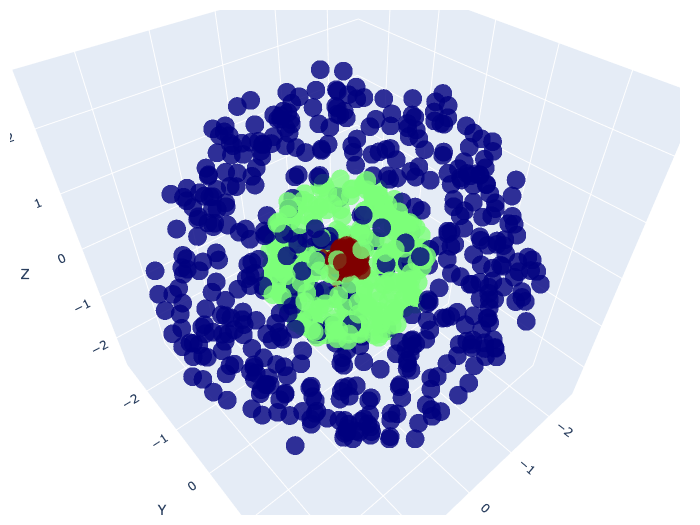

In [280]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# Loading the dataset
df3 = pd.read_csv("data/dataset3.csv", header=None)
df3.columns = ["x", "y", "z"]

# Use DBSCAN to do the clustering
clustering = DBSCAN(eps=0.7, min_samples=1).fit(df3)
labels = clustering.labels_

# Map each label to a color; we'll use the jet colormap here, but you can use any colormap you like
unique_labels = np.unique(labels)
colors = plt.cm.jet(np.linspace(0, 1, len(unique_labels)))

# Convert colors to format that plotly understands
colors = ["rgb" + str(tuple((color[:3] * 255).astype(int))) for color in colors]

# Map labels to corresponding color
label_color_map = dict(zip(unique_labels, colors))
label_colors = [label_color_map[label] for label in labels]

# Create a 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=df3['x'],
    y=df3['y'],
    z=df3['z'],
    mode='markers',
    marker=dict(
        size=6,
        color=label_colors,                
        opacity=0.8
    )
)])

# Set labels
fig.update_layout(scene = dict(
                    xaxis_title='X',
                    yaxis_title='Y',
                    zaxis_title='Z'),
                    width=700,
                    margin=dict(r=20, l=10, b=10, t=10))

fig.show()
Image(filename='newplot1.png')

Description:
Two concentric spherical surfaces of different sizes and a concentric sphere


Dataset 4.

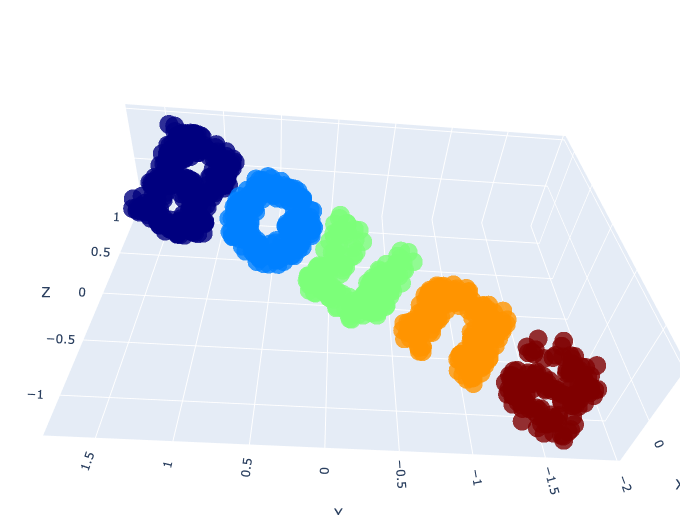

In [281]:
from sklearn.cluster import DBSCAN
from sklearn.manifold import MDS
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# Load dataset 4
df4 = pd.read_csv("data/dataset4.csv", header=None)

# Perform MDS to reduce dimension to 3
mds = MDS(n_components=3, normalized_stress='auto')  # add normalized_stress='auto' to suppress the warning
X_transformed = mds.fit_transform(df4)

# Use DBSCAN to do the clustering
clustering = DBSCAN(eps=0.141, min_samples=4).fit(X_transformed)
labels = clustering.labels_

# Map each label to a color; we'll use the jet colormap here, but you can use any colormap you like
unique_labels = np.unique(labels)
colors = plt.cm.jet(np.linspace(0, 1, len(unique_labels)))

# Convert colors to format that plotly understands
colors = ["rgb" + str(tuple((color[:3] * 255).astype(int))) for color in colors]

# Map labels to corresponding color
label_color_map = dict(zip(unique_labels, colors))
label_colors = [label_color_map[label] for label in labels]

# Create a 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=X_transformed[:, 0],
    y=X_transformed[:, 1],
    z=X_transformed[:, 2],
    mode='markers',
    marker=dict(
        size=6,
        color=label_colors,                
        opacity=0.8
    )
)])

# Set labels
fig.update_layout(scene = dict(
                    xaxis_title='X',
                    yaxis_title='Y',
                    zaxis_title='Z'),
                    width=700,
                    margin=dict(r=20, l=10, b=10, t=10))

Image(filename='newplot2.png')


Description:
The three-dimensional image after MDS is a projection of the word BONUS on an I-beam shape


Dataset 5.

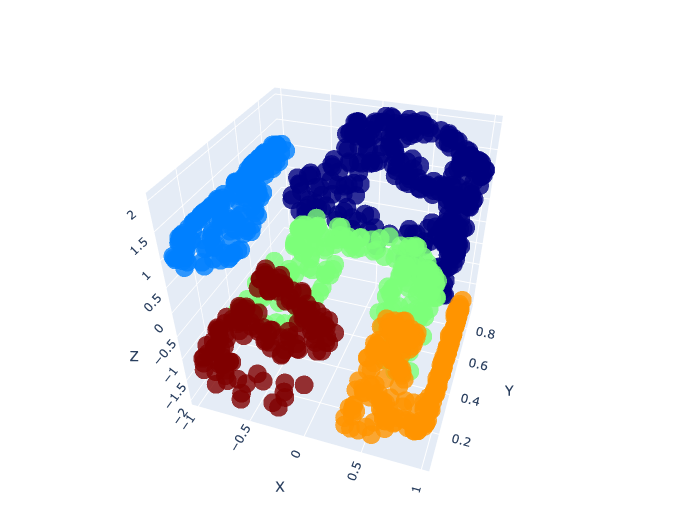

In [282]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# Load dataset 5
df5 = pd.read_csv("data/dataset5.csv", header=None)
df5.columns = ["x", "y", "z"]

# Use DBSCAN to do the clustering
clustering = DBSCAN(eps=0.3, min_samples=8).fit(df5)
labels = clustering.labels_

# Map each label to a color; we'll use the jet colormap here, but you can use any colormap you like
unique_labels = np.unique(labels)
colors = plt.cm.jet(np.linspace(0, 1, len(unique_labels)))

# Convert colors to format that plotly understands
colors = ["rgb" + str(tuple((color[:3] * 255).astype(int))) for color in colors]

# Map labels to corresponding color
label_color_map = dict(zip(unique_labels, colors))
label_colors = [label_color_map[label] for label in labels]

# Create a 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=df5['x'],
    y=df5['y'],
    z=df5['z'],
    mode='markers',
    marker=dict(
        size=6,
        color=label_colors,                
        opacity=0.8
    )
)])

# Set labels
fig.update_layout(scene = dict(
                    xaxis_title='X',
                    yaxis_title='Y',
                    zaxis_title='Z'),
                    width=700,
                    margin=dict(r=20, l=10, b=10, t=10))

fig.show()

Image(filename='newplot3.png')

Description:

One by the word BONUS is twisted into an S-shape in 3D space

## Part 3. Multi-dimensional Scaling and PCA

This question is continued  from part 5 in project 2, where we continue to use `data2.csv`

- 1. Use Multi-dimensional Scaling to plot the points in data2, label the clusters by different colors.
- 2. Use PCA to get the first two pc scores and plot them  with different colors indicating different clusters.
- 3. The colors should be the same for the same cluster.

In [283]:
data=pd.read_csv("data/data2.csv",header=None)
data.columns=["x","y","t1","t2","t3","label"]

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/manifold/_mds.py:299: FutureWarning:

The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.



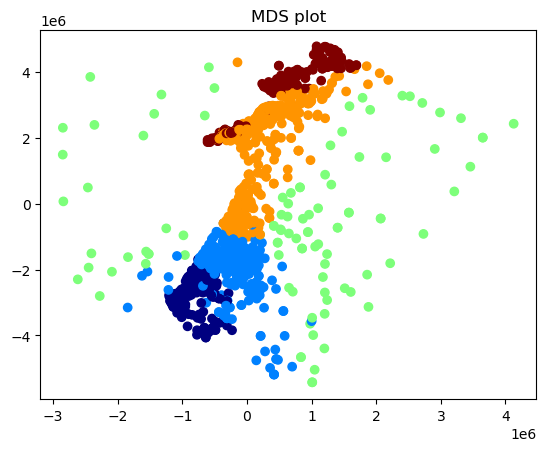

In [284]:
from sklearn.decomposition import PCA
data = data.dropna()

## MDS plot

mds = MDS(n_components=2)
X_transformed_mds = mds.fit_transform(data[["x", "y", "t1", "t2", "t3"]])

# Perform PCA
pca = PCA(n_components=2)
X_transformed_pca = pca.fit_transform(data[["x", "y", "t1", "t2", "t3"]])

# Map each label to a color
unique_labels = data['label'].unique()
colors = plt.cm.jet(np.linspace(0, 1, len(unique_labels)))
label_color_map = dict(zip(unique_labels, colors))
label_colors = data['label'].map(label_color_map)

# Create the MDS plot
plt.scatter(X_transformed_mds[:, 0], X_transformed_mds[:, 1], c=label_colors)
plt.title('MDS plot')
plt.show()






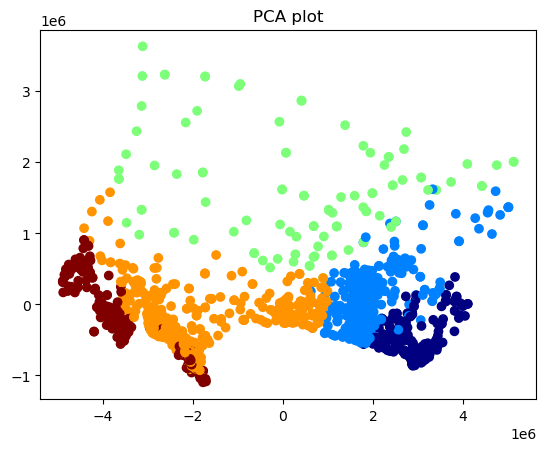

In [285]:
## PCA plot




# Create the PCA plot
plt.scatter(X_transformed_pca[:, 0], X_transformed_pca[:, 1], c=label_colors)
plt.title('PCA plot')
plt.show()


Q: Comparing the two plots, which one is better? Why?

A: PCA is a linear method that may not work well for downscaling and visualization of nonlinearly structured data.MDS can handle nonlinearly structured data and is able to maintain the distance between data points in low-dimensional space as much as possible. However, MDS may sometimes sacrifice other important properties of the data while trying to maintain distances. the results of PCA look better because PCA successfully preserves the geographic location (x,y) and is able to perform clustering on the map. This is because there is a strong geographic location effect in the data (e.g., nearby places may have a more similar climate), and this effect is well preserved in PCA.

## (Extra credit problem) Image segmentation

Image segmentation is to divide an image into subparts which have different meanings. For example, it can be divided into different objects such as the sky, cars, road etc. Or it can be divided into parts with different textures.

Perform a segmentation analysis on the following photo. The data folder includes data.png along with $48$ pre-processed feature files (each feature contains certain information). In case you are wondering, these features are generated through certain image processing methods, including image filtering and convolutinal kernels. Different features emphasize different asepcts of the image. For example, some show clear edges, while some are good at identifying corners.

(Together with the 3 color channels in the original figure, we have in total 51 features.)

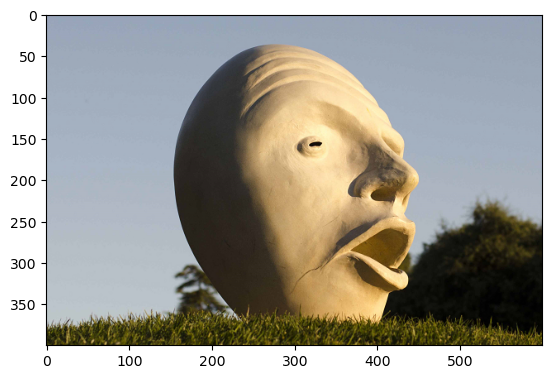

(400, 600, 3)
(400, 600, 48)


In [286]:
# Load the image and features, plot the image.
# Do not change the code
image = imread('data/data.png')
image = image[:,:,:3]
plt.imshow(image)
plt.show()

feature = np.zeros((image.shape[0],image.shape[1], 48))

for i in range(48):
    feature[:,:,i] = genfromtxt('data/features/feature'+str(i), delimiter=',')

print(image.shape)
print(feature.shape)

Provide two segmentation plots, each with different emphasis. One plot is to identify the meaning objects, the other is to idenity regions with different textures.

You can use any method you learned in this cource. The simplest example is to use k-means.

Hint: carefully choose the features. You may need to look at each feature one by one to understand its meaning (use `plt.imshow`)

/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



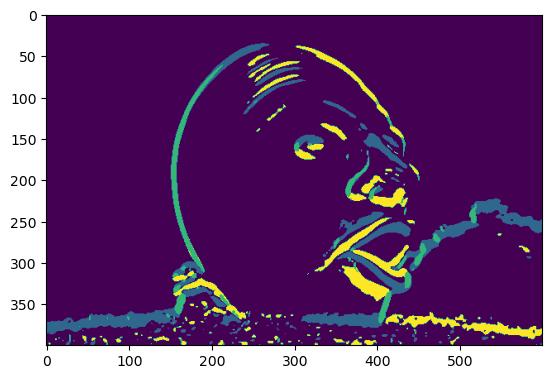

In [287]:
# Identify the objects

from sklearn.cluster import KMeans


selected_indices = [0, 1, 2, 3, 4, 5, 6, 7, 18, 19, 23, 30, 47]
selected_features = feature[:,:,selected_indices] 

# Reshape the selected features
reshaped_feature = np.reshape(selected_features, (selected_features.shape[0]*selected_features.shape[1], len(selected_indices)))

# Apply KMeans
kmeans = KMeans(n_clusters=4) # change the number of clusters to see different results
labels = kmeans.fit_predict(reshaped_feature)

# Reshape the labels back to the original image shape
segmented_image = np.reshape(labels, (image.shape[0], image.shape[1]))


plt.imshow(segmented_image)
plt.show()







/Users/t0m/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



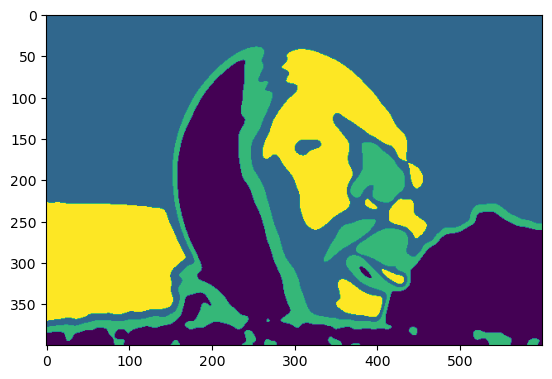

In [288]:
# Identify the parts with different textures


from sklearn.cluster import KMeans


selected_indices = [3, 4, 7, 8, 9, 10, 11, 12, 14, 15, 16, 20, 21, 27, 28, 33, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47]
selected_features = feature[:,:,selected_indices] 

# Reshape the selected features
reshaped_feature = np.reshape(selected_features, (selected_features.shape[0]*selected_features.shape[1], len(selected_indices)))

# Apply KMeans
kmeans = KMeans(n_clusters=4) # change the number of clusters to see different results
labels = kmeans.fit_predict(reshaped_feature)

# Reshape the labels back to the original image shape
segmented_image = np.reshape(labels, (image.shape[0], image.shape[1]))


plt.imshow(segmented_image)
plt.show()




